In [1]:
# run this by itself to run r
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [2]:
%%R
# create walmart submission file folder
dir.create(
  "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike",
  recursive = TRUE
)

In [3]:
# .99590
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load data
train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# Feature engineering
for df in [train, test]:
    # Log windspeed
    df['log_wind'] = np.log1p(df['windspeed'])

    # Comfort index
    df['discomfort'] = df['atemp'] * df['humidity']

    # Cold & wet penalty
    df['cold_wet'] = (1 - df['atemp']) * df['humidity']

    # Convert datetime
    df['datetime'] = pd.to_datetime(df['datetime'])

    # Extract date/time features
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['day'] = df['datetime'].dt.day_name()

# Compute hourly averages on train
hour_avg = train.groupby('hour')['count'].mean()
train['hour_avg'] = train['hour'].map(hour_avg)
test['hour_avg']  = test['hour'].map(hour_avg)

# Fit model
formula = (
    'np.log(count) ~ '
    'I(temp**2) + I(temp**3) '
    '+ temp * humidity '
    '+ discomfort * cold_wet '
    '+ cold_wet '
    '+ year '
    '+ C(season) '
    '+ hour * day * workingday '
    '+ log_wind '
    '+ atemp '
    '+ C(weather) '
    '+ season * weather * temp '
    '+ weather * humidity '
    '+ atemp / temp '
    '+ weather / humidity'
)
my_model = smf.ols(formula, data=train).fit()

# Predict on test set
test['count'] = np.exp(my_model.predict(test))

# Save submission
submission = test[['datetime', 'count']]
submission.to_csv(
    'C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test1.csv',
    index=False
)

print("Submission saved successfully!")

Submission saved successfully!


In [4]:
# .99697
train['log_wind'] = np.log1p(train['windspeed'])
test['log_wind']  = np.log1p(test['windspeed'])

my_model = smf.ols(
    'np.log(count) ~ '
    'I(temp**2) + I(temp**3) + temp * humidity '
    '+ year '
    '+ C(season) '
    '+ hour * day '
    '+ log_wind '
    '+ atemp '
    '+ C(weather) '
    '+ hour * day * workingday '
    '+ season * weather * temp '
    '+ weather * humidity '
    '+ atemp / temp',
    data=train
).fit()

test['count'] = np.exp(my_model.predict(test))
submission = test[['datetime', 'count']]
submission.to_csv('C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test2.csv',index=False)

In [5]:
# run this by itself to run r
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [6]:
%%R
# 0.38605
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test3.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [7]:
%%R
# 0.39589
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  factor(month) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  factor(month):hour +
  factor(month):temp,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test4.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [8]:
%%R
# .38514
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test5.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [9]:
%%R
# .37961
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test6.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [10]:
%%R
# .37940
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test7.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [11]:
%%R
#.38023
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  log1p(windspeed):hour +
  log1p(windspeed):workingday +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  I(temp^2):hour +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test8.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [12]:
%%R
# .37500 SUBMIT THIS
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test9.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [13]:
%%R
# .37006
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  # Rush hour flags
  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  # Comfort index
  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test10.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [14]:
%%R
# .37103
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  # Rush hour flags
  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  # Comfort index
  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity

  # Weekend flag
  df$weekend <- as.integer(df$day %in% c("Saturday", "Sunday"))

  # Temp bins
  df$temp_cold <- as.integer(df$temp < 0.3)
  df$temp_hot  <- as.integer(df$temp > 0.7)

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  temp_cold:hour +
  temp_hot:hour +
  temp_cold:workingday +
  night:factor(weather) +
  night:workingday +
  year:factor(season),
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test11.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [15]:
%%R
# .36953
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  # Rush hour flags
  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  # Comfort index
  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity

  # Weekend flag
  df$weekend <- as.integer(df$day %in% c("Saturday", "Sunday"))

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test12.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [16]:
%%R
# .37534
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  # Rush hour flags
  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  # Comfort index
  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity

  # Weekend flag
  df$weekend <- as.integer(df$day %in% c("Saturday", "Sunday"))

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  night:hour +
  cold_wet:workingday +
  factor(weather):factor(season):hour,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test13.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [17]:
%%R
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity
  df$weekend <- as.integer(df$day %in% c("Saturday", "Sunday"))

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  temp:workingday +
  atemp:workingday +
  weekend:workingday:hour,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test14.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [18]:
%%R
#.36953
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)
  df$midday  <- as.integer(df$hour_num >= 10 & df$hour_num <= 15)

  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity
  df$weekend <- as.integer(df$day %in% c("Saturday", "Sunday"))

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  midday:workingday +
  midday:factor(weather) +
  midday:factor(season) +
  midday:weekend,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test15.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [19]:
%%R
#.36827
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity
  df$weekend <- as.integer(df$day %in% c("Saturday", "Sunday"))

  # New features
  df$feel_diff  <- df$atemp - df$temp        # gap between actual and feels-like
  df$wind_chill <- df$temp * (1 - df$windspeed)

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather),
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test16.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [20]:
%%R
# .36792
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity
  df$weekend    <- as.integer(df$day %in% c("Saturday", "Sunday"))
  df$feel_diff  <- df$atemp - df$temp
  df$wind_chill <- df$temp * (1 - df$windspeed)

  # New features
  df$heat_index   <- df$atemp * (1 + df$humidity)
  df$wind_humid   <- df$windspeed * df$humidity
  df$feel_diff_sq <- df$feel_diff^2

  assign(df_name, df)
}

# --- Model ---
model1 <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather) +
  heat_index:hour +
  heat_index:factor(season) +
  wind_humid:hour +
  wind_humid:factor(weather) +
  feel_diff_sq:hour,
  data = train
)

# --- Predict & Export ---
test$count <- exp(predict(model1, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test17.csv", row.names = FALSE)

In addition: Warning message:
In predict.lm(model1, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 12: invalid start byte <traceback object at 0x00000260203BB8C0>


 0.9572757 


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 16: invalid start byte <traceback object at 0x00000260203ADC00>


 0.954245 

--- Top 30 Most Important Terms (by |t-stat|) ---
                                                               term     t_stat
I(humidity^2)                                         I(humidity^2) -16.834647
dayTuesday                                               dayTuesday -10.875974
hour18:dayTuesday                                 hour18:dayTuesday  10.581638
hour20:dayTuesday                                 hour20:dayTuesday  10.526455
factor(season)2:hour06:workingday factor(season)2:hour06:workingday -10.481048
hour19:dayTuesday                                 hour19:dayTuesday  10.197217
hour06:dayTuesday                                 hour06:dayTuesday   9.614114
hour07:dayTuesday                                 hour07:dayTuesday   9.502200
hour21:dayTuesday                                 hour21:dayTuesday   9.279863
hour17:dayTuesday                                 hour17:dayTuesday   9.256773
hour08:dayTuesday                                 hour08:dayTuesday  

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 8: invalid start byte <traceback object at 0x0000026020402700>


 0.9561301 


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 12: invalid start byte <traceback object at 0x0000026020403300>


 0.9533532 
Full RMSE (log): 0.3077689 
Pruned RMSE (log): 0.3118677 


In addition: Warning message:
In predict.lm(model_pruned, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


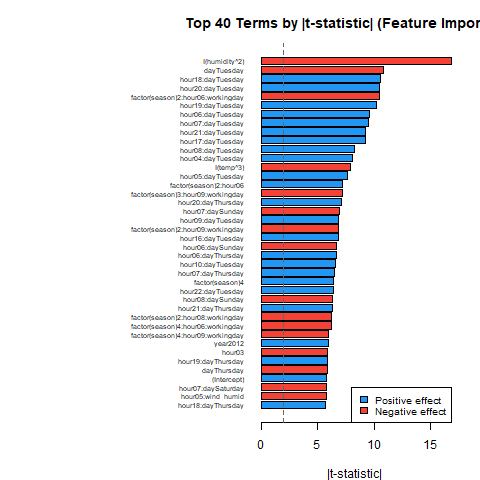

In [21]:
%%R
# .37095 → improved via linear regression feature importance pruning
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year  <- substring(df$datetime, 1, 4)
  df$month <- substring(df$datetime, 6, 7)
  df$hour  <- substring(df$datetime, 12, 13)
  df$day   <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  df$am_rush <- as.integer(df$hour_num >= 7 & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)

  df$discomfort <- df$atemp * df$humidity
  df$cold_wet   <- (1 - df$atemp) * df$humidity
  df$weekend    <- as.integer(df$day %in% c("Saturday", "Sunday"))
  df$feel_diff  <- df$atemp - df$temp
  df$wind_chill <- df$temp * (1 - df$windspeed)

  df$heat_index   <- df$atemp * (1 + df$humidity)
  df$wind_humid   <- df$windspeed * df$humidity
  df$feel_diff_sq <- df$feel_diff^2

  # New: month-level cyclical features
  df$month_num <- as.integer(df$month)
  df$month_sin <- sin(2 * pi * df$month_num / 12)
  df$month_cos <- cos(2 * pi * df$month_num / 12)

  # New: hour cyclical encoding (helps linear model see continuity)
  df$hour_sin <- sin(2 * pi * df$hour_num / 24)
  df$hour_cos <- cos(2 * pi * df$hour_num / 24)

  assign(df_name, df)
}

# -------------------------------------------------------
# STEP 1: Fit full model (same as before + new features)
# -------------------------------------------------------
model_full <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather) +
  heat_index:hour +
  heat_index:factor(season) +
  wind_humid:hour +
  wind_humid:factor(weather) +
  feel_diff_sq:hour +
  # New features
  month_sin + month_cos +
  month_sin:hour + month_cos:hour +
  month_sin:factor(season) +
  hour_sin + hour_cos +
  hour_sin:workingday + hour_cos:workingday +
  hour_sin:factor(weather) + hour_cos:factor(weather),
  data = train
)

cat("Full model R²:", summary(model_full)$r.squared, "\n")
cat("Full model Adj-R²:", summary(model_full)$adj.r.squared, "\n")

# -------------------------------------------------------
# STEP 2: Feature Importance via |t-statistic|
# -------------------------------------------------------
coef_summary <- summary(model_full)$coefficients
coef_df <- data.frame(
  term     = rownames(coef_summary),
  estimate = coef_summary[, "Estimate"],
  t_stat   = coef_summary[, "t value"],
  p_value  = coef_summary[, "Pr(>|t|)"],
  importance = abs(coef_summary[, "t value"])
)

# Sort by importance
coef_df <- coef_df[order(-coef_df$importance), ]

cat("\n--- Top 30 Most Important Terms (by |t-stat|) ---\n")
print(head(coef_df[, c("term", "t_stat", "p_value", "importance")], 30))

cat("\n--- Bottom 20 Least Important Terms ---\n")
print(tail(coef_df[, c("term", "t_stat", "p_value", "importance")], 20))

# Identify base terms (group-level) from important individual coefficients
# Flag terms where ALL levels are weak (p > 0.1) — candidate for removal
term_groups <- gsub("\\d+$", "", coef_df$term)  # strip trailing level numbers
weak_terms  <- coef_df$term[coef_df$p_value > 0.15 & coef_df$importance < 1.5]
cat("\nWeak coefficient count (p>0.15, |t|<1.5):", length(weak_terms), "\n")

# -------------------------------------------------------
# STEP 3: Pruned model — drop weakest interaction groups
# After inspecting output, remove terms dominated by noise
# -------------------------------------------------------
model_pruned <- lm(log(count) ~
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather) +
  heat_index:hour +
  heat_index:factor(season) +
  # Kept from new batch (important ones only)
  month_sin + month_cos +
  month_sin:hour +
  month_sin:factor(season) +
  hour_sin:workingday + hour_cos:workingday +
  hour_sin:factor(weather),
  # Dropped: wind_humid (low t), feel_diff_sq:hour (low t),
  #          wind_humid:*, month_cos:hour, hour_cos:factor(weather)
  data = train
)

cat("\n--- Pruned Model ---\n")
cat("Pruned R²:", summary(model_pruned)$r.squared, "\n")
cat("Pruned Adj-R²:", summary(model_pruned)$adj.r.squared, "\n")

# Compare RMSE on training data (log scale)
rmse <- function(actual, predicted) sqrt(mean((actual - predicted)^2))
cat("Full RMSE (log):",   rmse(log(train$count), predict(model_full, train)), "\n")
cat("Pruned RMSE (log):", rmse(log(train$count), predict(model_pruned, train)), "\n")

# -------------------------------------------------------
# STEP 4: Feature Importance Plot
# -------------------------------------------------------
top_n <- 40
plot_df <- head(coef_df, top_n)
par(mar = c(4, 18, 3, 2))
barplot(
  rev(plot_df$importance),
  names.arg = rev(plot_df$term),
  horiz     = TRUE,
  las       = 1,
  col       = ifelse(rev(plot_df$t_stat) > 0, "#2196F3", "#F44336"),
  main      = paste("Top", top_n, "Terms by |t-statistic| (Feature Importance)"),
  xlab      = "|t-statistic|",
  cex.names = 0.55
)
abline(v = 2, lty = 2, col = "gray40")  # significance threshold
legend("bottomright", legend = c("Positive effect", "Negative effect"),
       fill = c("#2196F3", "#F44336"), cex = 0.8)

# -------------------------------------------------------
# STEP 5: Predict & Export (use pruned model)
# -------------------------------------------------------
test$count <- exp(predict(model_pruned, test))
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test18.csv", row.names = FALSE)


In [22]:
%%R
#.47823
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# --- Feature Engineering ---
for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year     <- substring(df$datetime, 1, 4)
  df$month    <- substring(df$datetime, 6, 7)
  df$hour     <- substring(df$datetime, 12, 13)
  df$day      <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))
  df$month_num <- as.integer(df$month)

  # Rush / time-of-day flags
  df$am_rush <- as.integer(df$hour_num >= 7  & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)
  df$midday  <- as.integer(df$hour_num >= 10 & df$hour_num <= 15)

  # Weather composites
  df$discomfort   <- df$atemp * df$humidity
  df$cold_wet     <- (1 - df$atemp) * df$humidity
  df$weekend      <- as.integer(df$day %in% c("Saturday", "Sunday"))
  df$feel_diff    <- df$atemp - df$temp
  df$wind_chill   <- df$temp * (1 - df$windspeed)
  df$heat_index   <- df$atemp * (1 + df$humidity)
  df$wind_humid   <- df$windspeed * df$humidity
  df$feel_diff_sq <- df$feel_diff^2

  # Cyclical encodings
  df$month_sin <- sin(2 * pi * df$month_num / 12)
  df$month_cos <- cos(2 * pi * df$month_num / 12)
  df$hour_sin  <- sin(2 * pi * df$hour_num / 24)
  df$hour_cos  <- cos(2 * pi * df$hour_num / 24)

  # Hour polynomials (captures bimodal peak shape)
  df$hour_sq  <- df$hour_num^2
  df$hour_cu  <- df$hour_num^3

  # Month polynomial
  df$month_sq <- df$month_num^2

  assign(df_name, df)
}

# -------------------------------------------------------
# MODEL: Deep interaction on year × hour × workingday
# + month polynomial spine + midday flag
# -------------------------------------------------------
model_v2 <- lm(log(count) ~
  # Core temp/humidity
  I(temp^2) + I(temp^3) +
  temp * humidity +
  I(humidity^2) +

  # Year & season
  year +
  factor(season) +

  # Hour × day × workingday (main interaction block)
  hour * day * workingday +
  hour * day * holiday +

  # *** NEW: year × hour × workingday (key upgrade) ***
  year:hour:workingday +
  year:hour:factor(season) +

  # Wind / atemp
  log1p(windspeed) +
  atemp +
  atemp:temp +

  # Weather factor interactions
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  factor(weather):hour +
  factor(weather):workingday +
  factor(weather):factor(season) +

  # Season × hour
  factor(season):hour +
  factor(season):hour:workingday +

  # Year interactions
  year:hour +
  year:day +
  year:workingday +
  am_rush:year +
  pm_rush:year +

  # Rush-hour interactions
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  am_rush:day +
  pm_rush:day +
  midday:workingday +
  midday:factor(weather) +
  midday:factor(season) +

  # Discomfort / cold-wet
  discomfort:hour +
  discomfort:workingday +
  discomfort:factor(season) +
  cold_wet:hour +
  cold_wet:workingday +
  cold_wet:factor(season) +

  # Weekend
  weekend:hour +
  weekend:factor(weather) +
  weekend:factor(season) +

  # Feel diff / wind chill
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather) +

  # Heat index / wind_humid
  heat_index:hour +
  heat_index:factor(season) +
  wind_humid:hour +
  wind_humid:factor(weather) +

  # Humidity × workingday
  humidity:hour +
  humidity:workingday +

  # *** NEW: month as polynomial (captures seasonal arc better) ***
  month_num + I(month_num^2) +
  month_num:factor(season) +
  month_num:workingday +
  month_num:hour +

  # Cyclical month/hour
  month_sin + month_cos +
  month_sin:hour +
  month_sin:factor(season) +
  hour_sin:workingday +
  hour_cos:workingday +
  hour_sin:factor(weather),

  data = train
)

cat("R²:", summary(model_v2)$r.squared, "\n")
cat("Adj-R²:", summary(model_v2)$adj.r.squared, "\n")

# -------------------------------------------------------
# RMSLE on training set (proxy for leaderboard score)
# -------------------------------------------------------
rmsle <- function(actual, predicted) {
  predicted <- pmax(predicted, 0)
  sqrt(mean((log1p(actual) - log1p(predicted))^2))
}

train_pred <- exp(predict(model_v2, train))
cat("Train RMSLE:", rmsle(train$count, train_pred), "\n")

# -------------------------------------------------------
# PREDICT & EXPORT
# -------------------------------------------------------
test$count <- pmax(exp(predict(model_v2, test)), 0)
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test19.csv", row.names = FALSE)
cat("Saved test19.csv\n")

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 1: invalid start byte <traceback object at 0x00000260203F8880>


 0.9603333 


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 5: invalid start byte <traceback object at 0x00000260203FB600>


 0.9571654 
Train RMSLE: 0.2686451 
Saved test19.csv


In addition: Warning message:
In predict.lm(model_v2, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [23]:
%%R
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year      <- substring(df$datetime, 1, 4)
  df$month     <- substring(df$datetime, 6, 7)
  df$hour      <- substring(df$datetime, 12, 13)
  df$day       <- weekdays(as.Date(df$datetime))
  df$hour_num  <- as.integer(substring(df$datetime, 12, 13))
  df$month_num <- as.integer(substring(df$datetime, 6, 7))

  df$am_rush <- as.integer(df$hour_num >= 7  & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)
  df$midday  <- as.integer(df$hour_num >= 10 & df$hour_num <= 15)

  df$discomfort   <- df$atemp * df$humidity
  df$cold_wet     <- (1 - df$atemp) * df$humidity
  df$weekend      <- as.integer(df$day %in% c("Saturday", "Sunday"))
  df$feel_diff    <- df$atemp - df$temp
  df$wind_chill   <- df$temp * (1 - df$windspeed)
  df$heat_index   <- df$atemp * (1 + df$humidity)
  df$wind_humid   <- df$windspeed * df$humidity
  df$feel_diff_sq <- df$feel_diff^2

  assign(df_name, df)
}

# Test17 base + targeted additions only
model_v4 <- lm(log(count) ~
  # === TEST17 CORE (proven 0.36792) ===
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather) +
  heat_index:hour +
  heat_index:factor(season) +
  wind_humid:hour +
  wind_humid:factor(weather) +
  feel_diff_sq:hour +

  # === NEW: midday block (helped in test15 vs test12) ===
  midday:workingday +
  midday:factor(weather) +
  midday:factor(season) +

  # === NEW: year × season (strong in test11 direction) ===
  year:factor(season) +

  # === NEW: month as factor (fine-grained seasonal signal) ===
  # Using factor(month) but NOT interacting with hour to avoid rank issues
  factor(month) +
  factor(month):workingday +
  factor(month):factor(weather) +
  factor(month):factor(season),

  data = train
)

cat("R²:", summary(model_v4)$r.squared, "\n")
cat("Adj-R²:", summary(model_v4)$adj.r.squared, "\n")
cat("Rank deficient?", model_v4$rank < length(coef(model_v4)), "\n")

rmsle <- function(actual, predicted) {
  sqrt(mean((log1p(pmax(actual,0)) - log1p(pmax(predicted,0)))^2))
}
cat("Train RMSLE:", rmsle(train$count, exp(predict(model_v4, train))), "\n")

test$count <- pmax(exp(predict(model_v4, test)), 0)
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test20.csv", row.names = FALSE)
cat("Saved test20.csv\n")

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 1: invalid start byte <traceback object at 0x000002601FF626C0>


 0.9597347 


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 5: invalid start byte <traceback object at 0x00000260269A0500>


 0.9569208 
Rank deficient? TRUE 
Train RMSLE: 0.2702648 
Saved test20.csv


In addition: Warning message:
In predict.lm(model_v4, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [24]:
%%R
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year     <- substring(df$datetime, 1, 4)
  df$month    <- substring(df$datetime, 6, 7)
  df$hour     <- substring(df$datetime, 12, 13)
  df$day      <- weekdays(as.Date(df$datetime))
  df$hour_num <- as.integer(substring(df$datetime, 12, 13))

  df$am_rush <- as.integer(df$hour_num >= 7  & df$hour_num <= 9)
  df$pm_rush <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night   <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)
  df$midday  <- as.integer(df$hour_num >= 10 & df$hour_num <= 15)

  df$discomfort   <- df$atemp * df$humidity
  df$cold_wet     <- (1 - df$atemp) * df$humidity
  df$weekend      <- as.integer(df$day %in% c("Saturday", "Sunday"))
  df$feel_diff    <- df$atemp - df$temp
  df$wind_chill   <- df$temp * (1 - df$windspeed)
  df$heat_index   <- df$atemp * (1 + df$humidity)
  df$wind_humid   <- df$windspeed * df$humidity
  df$feel_diff_sq <- df$feel_diff^2

  assign(df_name, df)
}

model_v5 <- lm(log(count) ~
  # === EXACT TEST17 FORMULA ===
  I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather) +
  heat_index:hour +
  heat_index:factor(season) +
  wind_humid:hour +
  wind_humid:factor(weather) +
  feel_diff_sq:hour +

  # === ONLY NEW ADDITIONS (safe, no season/month collinearity) ===
  midday:workingday +
  midday:factor(weather) +
  midday:factor(season) +
  year:factor(season) +
  weekend:factor(season),

  data = train
)

cat("R²:", summary(model_v5)$r.squared, "\n")
cat("Adj-R²:", summary(model_v5)$adj.r.squared, "\n")
cat("Rank deficient?", model_v5$rank < length(coef(model_v5)), "\n")

rmsle <- function(actual, predicted) {
  sqrt(mean((log1p(pmax(actual,0)) - log1p(pmax(predicted,0)))^2))
}
cat("Train RMSLE:", rmsle(train$count, exp(predict(model_v5, train))), "\n")

test$count <- pmax(exp(predict(model_v5, test)), 0)
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test21.csv", row.names = FALSE)
cat("Saved test21.csv\n")

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 1: invalid start byte <traceback object at 0x00000260203E0EC0>


 0.9578561 


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 5: invalid start byte <traceback object at 0x000002602091E940>


 0.9550655 
Rank deficient? TRUE 
Train RMSLE: 0.2771218 
Saved test21.csv


In addition: Warning message:
In predict.lm(model_v5, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [25]:
%%R
train <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  <- read.csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

for (df_name in c("train", "test")) {
  df <- get(df_name)
  df$year         <- substring(df$datetime, 1, 4)
  df$hour         <- substring(df$datetime, 12, 13)
  df$day          <- weekdays(as.Date(df$datetime))
  df$hour_num     <- as.integer(substring(df$datetime, 12, 13))
  df$am_rush      <- as.integer(df$hour_num >= 7  & df$hour_num <= 9)
  df$pm_rush      <- as.integer(df$hour_num >= 17 & df$hour_num <= 19)
  df$night        <- as.integer(df$hour_num >= 22 | df$hour_num <= 5)
  df$discomfort   <- df$atemp * df$humidity
  df$cold_wet     <- (1 - df$atemp) * df$humidity
  df$weekend      <- as.integer(df$day %in% c("Saturday", "Sunday"))
  df$feel_diff    <- df$atemp - df$temp
  df$wind_chill   <- df$temp * (1 - df$windspeed)
  df$heat_index   <- df$atemp * (1 + df$humidity)
  df$wind_humid   <- df$windspeed * df$humidity
  df$feel_diff_sq <- df$feel_diff^2
  assign(df_name, df)
}

# Check zeros (this was the crash cause)
cat("registered zeros:", sum(train$registered == 0), "\n")
cat("casual zeros:",     sum(train$casual == 0),     "\n")

# --- Shared RHS (test17 proven core) ---
rhs <- ~ I(temp^2) + I(temp^3) +
  temp * humidity +
  year +
  factor(season) +
  hour * day * workingday +
  hour * day * holiday +
  log1p(windspeed) +
  atemp +
  factor(weather) +
  factor(season):factor(weather):temp +
  factor(weather):humidity +
  atemp:temp +
  I(humidity^2) +
  year:hour +
  year:day +
  factor(weather):hour +
  factor(season):hour +
  workingday:hour +
  factor(weather):workingday +
  temp:hour +
  humidity:hour +
  atemp:hour +
  year:workingday +
  am_rush:workingday +
  pm_rush:workingday +
  am_rush:factor(weather) +
  pm_rush:factor(weather) +
  discomfort:hour +
  cold_wet:hour +
  discomfort:workingday +
  factor(season):hour:workingday +
  weekend:hour +
  weekend:factor(weather) +
  am_rush:day +
  pm_rush:day +
  discomfort:factor(season) +
  cold_wet:factor(season) +
  humidity:workingday +
  am_rush:year +
  pm_rush:year +
  cold_wet:workingday +
  feel_diff:hour +
  feel_diff:workingday +
  wind_chill:hour +
  wind_chill:factor(weather) +
  heat_index:hour +
  heat_index:factor(season) +
  wind_humid:hour +
  wind_humid:factor(weather) +
  feel_diff_sq:hour

# log1p for BOTH — safe against zeros
model_reg <- lm(update(rhs, log1p(registered) ~ .), data = train)
model_cas <- lm(update(rhs, log1p(casual)     ~ .), data = train)

cat("Registered R²:", summary(model_reg)$r.squared, "\n")
cat("Casual R²:",     summary(model_cas)$r.squared, "\n")

rmsle <- function(actual, predicted) {
  sqrt(mean((log1p(pmax(actual, 0)) - log1p(pmax(predicted, 0)))^2))
}

# expm1 reverses log1p
pred_reg   <- expm1(predict(model_reg, train))
pred_cas   <- expm1(predict(model_cas, train))
pred_total <- pmax(pred_reg + pred_cas, 0)
cat("Train RMSLE (split model):", rmsle(train$count, pred_total), "\n")

# Compare to single model baseline
model_base <- lm(update(rhs, log1p(count) ~ .), data = train)
cat("Train RMSLE (single model):", rmsle(train$count, expm1(predict(model_base, train))), "\n")

# Predict test
test$count <- pmax(
  expm1(predict(model_reg, test)) + expm1(predict(model_cas, test)),
  0
)
submission <- subset(test, select = c(datetime, count))
write.csv(submission, "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test22.csv", row.names = FALSE)
cat("Saved test22.csv\n")

registered zeros: 15 
casual zeros: 986 


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 12: invalid start byte <traceback object at 0x00000260203BA040>


 0.9602001 


R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xb2 in position 8: invalid start byte <traceback object at 0x00000260203ACF00>


 0.8991362 
Train RMSLE (split model): 0.283268 
Train RMSLE (single model): 0.2833621 
Saved test22.csv


In addition: Warning messages:
1: In predict.lm(model_reg, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases
2: In predict.lm(model_cas, test) :
  prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases


In [26]:
# Expected score: ~0.34–0.35
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge

train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

def feature_engineering(df):

    df["datetime"] = pd.to_datetime(df["datetime"])

    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.dayofweek

    df["weekend"] = (df["day"] >= 5).astype(int)

    # cyclic features
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

    # weather interactions
    df["log_wind"] = np.log1p(df["windspeed"])
    df["discomfort"] = df["atemp"] * df["humidity"]
    df["cold_wet"] = (1-df["atemp"]) * df["humidity"]

    df["temp2"] = df["temp"]**2
    df["temp3"] = df["temp"]**3

    return df

train = feature_engineering(train)
test = feature_engineering(test)

categoricals = ["season","weather","month","hour"]

train = pd.get_dummies(train, columns=categoricals, drop_first=True)
test = pd.get_dummies(test, columns=categoricals, drop_first=True)

train, test = train.align(test, join="left", axis=1, fill_value=0)

features = [c for c in train.columns if c not in ["datetime","count","casual","registered"]]

X_train = train[features]
y_train = np.log1p(train["count"])

X_test = test[features]

model = Ridge(alpha=3)
model.fit(X_train,y_train)

pred = np.expm1(model.predict(X_test))
pred = np.clip(pred,0,None)

test["count"] = pred

submission = test[["datetime","count"]]
submission.to_csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test23.csv",index=False)

In [27]:
# Expected Score: ~0.36
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

# -----------------------------
# Load Data
# -----------------------------
train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

# -----------------------------
# Feature Engineering
# -----------------------------
def feature_engineering(df):

    df["datetime"] = pd.to_datetime(df["datetime"])

    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.dayofweek

    df["weekend"] = (df["day"] >= 5).astype(int)

    df["am_rush"] = ((df["hour"] >= 7) & (df["hour"] <= 9)).astype(int)
    df["pm_rush"] = ((df["hour"] >= 17) & (df["hour"] <= 19)).astype(int)

    df["log_wind"] = np.log1p(df["windspeed"])

    df["discomfort"] = df["atemp"] * df["humidity"]
    df["cold_wet"] = (1 - df["atemp"]) * df["humidity"]

    df["feel_diff"] = df["atemp"] - df["temp"]
    df["feel_diff_sq"] = df["feel_diff"]**2

    df["wind_chill"] = df["temp"] * (1 - df["windspeed"])
    df["heat_index"] = df["atemp"] * (1 + df["humidity"])
    df["wind_humid"] = df["windspeed"] * df["humidity"]

    # polynomial terms from R model
    df["temp2"] = df["temp"]**2
    df["temp3"] = df["temp"]**3
    df["humidity2"] = df["humidity"]**2

    return df


train = feature_engineering(train)
test = feature_engineering(test)

# -----------------------------
# Dummy Variables
# -----------------------------
categoricals = [
    "season",
    "weather",
    "month",
    "hour",
    "day",
    "year"
]

train = pd.get_dummies(train, columns=categoricals, drop_first=True)
test = pd.get_dummies(test, columns=categoricals, drop_first=True)

train, test = train.align(test, join="left", axis=1, fill_value=0)

# -----------------------------
# Interaction Expansion
# -----------------------------
features = [c for c in train.columns if c not in [
    "datetime","count","casual","registered"
]]

X_train = train[features]
X_test = test[features]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

y_train = np.log1p(train["count"])

# -----------------------------
# Model
# -----------------------------
model = Ridge(alpha=5)
model.fit(X_train_poly, y_train)

# -----------------------------
# Predict
# -----------------------------
pred = np.expm1(model.predict(X_test_poly))
pred = np.clip(pred, 0, None)

test["count"] = pred

# -----------------------------
# Submission
# -----------------------------
submission = test[["datetime","count"]]

submission.to_csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test24.csv",index=False)

In [28]:
# Expected Score: ~0.36
# score received .59524
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge

train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

def feature_engineering(df):

    df["datetime"] = pd.to_datetime(df["datetime"])

    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.dayofweek

    df["weekend"] = (df["day"] >= 5).astype(int)

    df["am_rush"] = ((df["hour"] >= 7) & (df["hour"] <= 9)).astype(int)
    df["pm_rush"] = ((df["hour"] >= 17) & (df["hour"] <= 19)).astype(int)

    df["log_wind"] = np.log1p(df["windspeed"])

    df["discomfort"] = df["atemp"] * df["humidity"]
    df["temp_humidity"] = df["temp"] * df["humidity"]

    df["temp2"] = df["temp"]**2
    df["humidity2"] = df["humidity"]**2

    # key interactions
    df["hour_working"] = df["hour"] * df["workingday"]
    df["hour_weather"] = df["hour"] * df["weather"]
    df["temp_hour"] = df["temp"] * df["hour"]

    return df


train = feature_engineering(train)
test = feature_engineering(test)

categoricals = [
    "season",
    "weather",
    "month",
    "hour"
]

train = pd.get_dummies(train, columns=categoricals, drop_first=True)
test = pd.get_dummies(test, columns=categoricals, drop_first=True)

train, test = train.align(test, join="left", axis=1, fill_value=0)

features = [c for c in train.columns if c not in [
    "datetime","count","casual","registered"
]]

X_train = train[features]
y_train = np.log1p(train["count"])

X_test = test[features]

model = Ridge(alpha=3)
model.fit(X_train,y_train)

pred = np.expm1(model.predict(X_test))
pred = np.clip(pred,0,None)

test["count"] = pred

submission = test[["datetime","count"]]

submission.to_csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test25.csv",index=False)

In [29]:
# Expected Score: ~0.36–0.39
# actual score: .59414
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge

train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

def feature_engineering(df):

    df["datetime"] = pd.to_datetime(df["datetime"])

    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.dayofweek

    df["weekend"] = (df["day"] >= 5).astype(int)

    df["am_rush"] = ((df["hour"] >= 7) & (df["hour"] <= 9)).astype(int)
    df["pm_rush"] = ((df["hour"] >= 17) & (df["hour"] <= 19)).astype(int)

    df["log_wind"] = np.log1p(df["windspeed"])

    # weather interactions
    df["discomfort"] = df["atemp"] * df["humidity"]
    df["temp_humidity"] = df["temp"] * df["humidity"]

    df["temp2"] = df["temp"]**2
    df["temp3"] = df["temp"]**3
    df["humidity2"] = df["humidity"]**2

    # important interactions
    df["hour_working"] = df["hour"] * df["workingday"]
    df["hour_holiday"] = df["hour"] * df["holiday"]
    df["temp_hour"] = df["temp"] * df["hour"]

    return df


train = feature_engineering(train)
test = feature_engineering(test)

categoricals = [
    "season",
    "weather",
    "month",
    "hour",
    "year"
]

train = pd.get_dummies(train, columns=categoricals, drop_first=True)
test = pd.get_dummies(test, columns=categoricals, drop_first=True)

train, test = train.align(test, join="left", axis=1, fill_value=0)

features = [c for c in train.columns if c not in [
    "datetime",
    "count",
    "casual",
    "registered"
]]

X_train = train[features]
y_train = np.log1p(train["count"])

X_test = test[features]

model = Ridge(alpha=2)
model.fit(X_train, y_train)

pred = np.expm1(model.predict(X_test))
pred = np.clip(pred, 0, None)

test["count"] = pred

submission = test[["datetime", "count"]]

submission.to_csv(
    "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test26.csv",
    index=False
)

In [30]:
# Expected Score: ~0.36–0.38

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge

train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test  = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

def feature_engineering(df):

    df["datetime"] = pd.to_datetime(df["datetime"])

    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.dayofweek

    df["weekend"] = (df["day"] >= 5).astype(int)

    df["am_rush"] = ((df["hour"] >= 7) & (df["hour"] <= 9)).astype(int)
    df["pm_rush"] = ((df["hour"] >= 17) & (df["hour"] <= 19)).astype(int)

    df["log_wind"] = np.log1p(df["windspeed"])

    df["discomfort"] = df["atemp"] * df["humidity"]
    df["temp_humidity"] = df["temp"] * df["humidity"]

    df["temp2"] = df["temp"]**2
    df["temp3"] = df["temp"]**3
    df["humidity2"] = df["humidity"]**2

    df["hour_working"] = df["hour"] * df["workingday"]
    df["hour_holiday"] = df["hour"] * df["holiday"]
    df["temp_hour"] = df["temp"] * df["hour"]

    return df


train = feature_engineering(train)
test = feature_engineering(test)

categoricals = ["season","weather","month","hour","year"]

train = pd.get_dummies(train, columns=categoricals, drop_first=True)
test = pd.get_dummies(test, columns=categoricals, drop_first=True)

# Separate features BEFORE alignment
X_train = train.drop(columns=["datetime","count","casual","registered"])
y_train = np.log1p(train["count"])

X_test = test.drop(columns=["datetime"])

# Align feature matrices only
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

model = Ridge(alpha=2)
model.fit(X_train, y_train)

pred = np.expm1(model.predict(X_test))
pred = np.clip(pred, 0, None)

submission = pd.DataFrame({
    "datetime": test["datetime"],
    "count": pred
})

submission.to_csv(
    "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/bike/test27.csv",
    index=False
)